**Made by LARBAOUI Yasmine Badr Elhouda**

In this notebook , I impemented a **time series forecasting** model using a **Transformer neural network**.

The goal is to predict **hourly household electricity consumption** using past consumption data.

#**Pipeline Overview**

1. data loading
2. data cleaning and preprocessing
3. data normalization
4. sequence creation
5. train-test split
6. transformer model construction
7. model training
8. model evaluation
9. result vizualization

##**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import requests
import io
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model


##**Data downloading and processing**


\- Load electricity Consumption dataset

\- Handle missing values and set datetime index

\- Resample to hourly averages

\- Scale data for neural network trainig

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
r = requests.get(url)
# extract ZIP file in the memory
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()


In [ ]:
df = pd.read_csv(

    "household_power_consumption.txt", # the dataset file

    sep=";",

    parse_dates={"Datetime": ["Date", "Time"]}, # combine date & time into dateTime column

    infer_datetime_format=True, # detect the date format

    low_memory=False,

    na_values=["?"] # consider (?) as missing values

)

/tmp/ipython-input-3349751333.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipython-input-3349751333.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
/tmp/ipython-input-3349751333.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


###**Keeping only the relevant columns and clean data**

In [ ]:
df = df[["Datetime", "Global_active_power"]] # keep datetime and power consumption
df.dropna(inplace=True) # remove rows with missing values
df.set_index("Datetime", inplace=True) # set datetime as index

###**Resample data to hourly averages**

for the predicting hourly consumption , averaging over each hour will reduce noise and make trainig easier

In [ ]:
df_hourly = df.resample("1H").mean() # average values for each hour

df_hourly = df_hourly.dropna() # drop rows with NaNs after resampling
# resampling can create empty hours -? remove them to avoid erros during training

/tmp/ipython-input-4147085508.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample("1H").mean()


###**Plot first 1000 hourly consumption values**

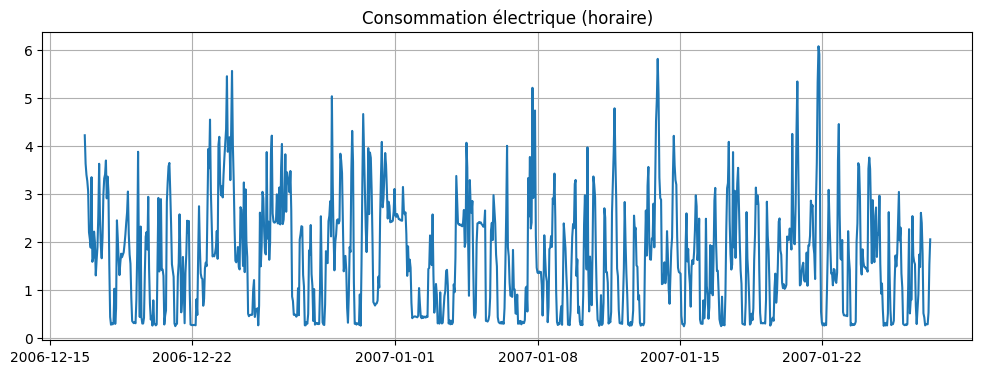

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df_hourly[:1000])
plt.title("Consommation électrique (horaire)")
plt.grid()
plt.show()


###**Data Normalization**

Normalizing the data so all the values are in the same range (0,1)

    faster training - more stably - more accurately when input values are scaled

    Scaling to 0-1 ensures all values are in the same range. Neural networks learn better with similar-sized numbers.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# converting the dataFrame into a Numpy Array
# then with fit_transform() find the max and min of each clumn
# and scale it using the min and max
data_scaled = scaler.fit_transform(df_hourly.values)


##**sequence creation**

###**Input-Output function for time-series**

Creating input-output sequences from time-series data
the transformer cannot work directly with raw time dtaa - so we transform the data into :    
\- X : Past values (input sequence)

\- y : next value to predict (target)

    converting the data into sequences where the model uses the last 24 hours as input and learns to predict the next hour.

exmple :    
- input sequence (X) : [hour0 , hour1 , ... , hour23]
- target (y) : hour24

In [ ]:
def create_sequences(data, window):
    # windows : number of past time steps used as input
    # data : scaled time-serie data

    X, y = [], [] = input and output lisy
    # x: store input sequences - past value
    # y: store output values - value to predict
    for i in range(len(data) - window): # loop through data to create sequences

        # Add a sequence of length 'window' to x
        # it represent the pas values input - to the model
        X.append(data[i:i+window])

        # add the value right after the sequence
        # this is the target value - the model should predict
        y.append(data[i+window])
    return np.array(X), np.array(y)


In [ ]:

WINDOW = 24  # Number of the past hours used for prediciton
# ex : used last 24 hour to predict the next hour

X, y = create_sequences(data_scaled, WINDOW) # create the sequences
# x contains the sequences of 24 hours
# and y contain the corresponding next-hour values

###**Trainig and testing datasets**

In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


##**Model Implementation :Transformer Block**

###**Positional Encoding Layer**

Transformers do not naturally understand the order of data.

This positional encoding layer adds information about the position of each **time step** using sine and cosine functions, allowing the model to learn **temporal relationships**.

- utilization of **since** and **cosine** because they give a unique continous pattern for each position

- the transformer can distinguish positions even if the sequences are longer than the trained length

In [ ]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model):
        # max_len : maximum length of the input sequence
        # d_model : dimension of the model = embedding size

        super().__init__() # Initialize the parent layer class

        # create a column vector of positions (0,1,....,max_len-1)
        pos = np.arange(max_len)[:, None]

        # create a row vector of feature indices (0 to d_model-1)
        i = np.arange(d_model)[None, :]

        #compute scaling gactors for each dimension
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))

        # compute angles for sine and cosine functions
        angle_rads = pos * angle_rates

        # initialize the positional encoding matrix
        pe = np.zeros((max_len, d_model))

        pe[:, 0::2] = np.sin(angle_rads[:, 0::2]) # Apply sine to even indices
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2]) # Apply cosine to odd indices

        self.pe = tf.constant(pe, dtype=tf.float32)  # Store positional encoding as a TensorFlow constant

    def call(self, x): # is called druring the forward pass
        # add positional encoding to the input tensor
        return x + self.pe[:tf.shape(x)[1]]


###**Model architecture**

This transformer block has 2 main parts :    
\- Self-attention : model looks at all the time steps and decides what is important

\- feed-forward Network : processes the information and learns patterns

**1. Multihead attention (self attention)**:
- Each time step in x looks at all other time steps in the sequence and decides how much to “pay attention” to them.

- x, x → sequence attends to itself → self-attention.

- num_heads=2 → the attention is computed twice in parallel, each focusing on different patterns (short-term vs long-term trends).

- key_dim=head_size → size of each head’s attention vector.

      Look at all past hours. Decide which hours are important for predicting the next hour. Do this multiple ways (heads) to capture different types of relationships.

**2. Add & Normalize** :    
- Add the attention output to the original input (x + attn) → skip connection.

- Keeps original info so the model doesn’t “forget” the raw sequence.

- Apply LayerNormalization → stabilize training, prevent exploding/vanishing values.

       Keeping the original sequence information, adding what the attention learned, and normalizing to keep numbers stable.

**3. Feed-Forward Network** :
- First Dense layer (Dense(ff_dim, activation="relu")) : transforms each time step vector into a higher-dimensional space to process complex patterns.

- Dropout : randomly removes connections to prevent overfitting.

- Second Dense layer (Dense(x.shape[-1])) :  bring vector back to original size so it can be added to x.

      Processing each time step individually to learn complex features, then bring it back to the same size so we can combine it with the input.”

4. **add & Noralize again**:
- Add the feed-forward output to the input (x + ff)  : another skip connection.

- Normalize again → stabilize training.

      Combine what we learned from the feed-forward network with the attention + original sequence, and normalize to keep values in a stable range.

In [ ]:
def transformer_encoder(x, head_size, num_heads, ff_dim, dropout):
# x : input sequence
# head_size : size of eac attention head
# num_heaads : number of attention head
# ff_dim : size of the feed-forward layer

    # multi head attention allows the model to focus on different
    # parts of the sequences at the same time
    attn = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(x, x) # mean self attention : sequence attends to itself

    x = LayerNormalization(epsilon=1e-6)(x + attn) # skip connection
    # add the attention output to the original input
    # helps keep original information and improves training
    # Layer Normalization to stabilizes learning

    ff = Dense(ff_dim, activation="relu")(x) # first feed forward layer
    # linear transformation followed by RELU Activation

    # dropout randomly remove some connections -> helps improve overfitting
    ff = Dropout(dropout)(ff)

    # second feed-forward layer
    # brings output back to the original feature size
    ff = Dense(x.shape[-1])(ff)

    return LayerNormalization(epsilon=1e-6)(x + ff) # another skip connection
    # add feed-forward output to the input
    # apply normalization again


**Step 1 : Input and projection**
- input is a sequence of numbers for 24 hours (24/1 value per hour)
- transofmrer cant work well with just 1 number per hour
- project the input : make each number into 32 numbers (d_model = 32)
- the dense layer does this by multiplying the input with wights -> creates a vector for each time step

**step 2 : positional encoding**
- ransformers dont know order . they see a bag of numbers
- positional encoding adds a pattern that tells the model ' this is hour 0 , this is hour 1 ' its like each number gets a tag with its position

**step 3 : transformer block**
- the transformer looks at all 24 hours at once and learn patterns
- selfattention decides which hours are important to predict the next hour
- feed-forward network processes the combined information
- residual connections + normalization keep the information safe and stabilize the trainig

**step 4 : take the last time step and predict**
- after the transformer , we have a vector for each hour
- we only care about the last hour because we want to predict the next one
- take the last vector and pass it through a dense layer -> output a single value -> prediction of next hour


  
      the transformer looked at the full 24 hours history and summirized it in the last hour vector -> now we read he summary and predcit hour 25

**step 5 : compiling the model**
- optimizer adam to adjust the weights efficiently
- loss MSE  tomeasures ho far predicitons are from real values

In [ ]:
d_model = 32 # size of the model : number of features in each time step after projection

# The input layer
inputs = Input(shape=(WINDOW, 1))  # 1= features per time step

# project the input from 1 feature to d_model features
# this allows the transformer to ork with richer representations
x = Dense(d_model)(inputs)

# add positional ecoding so the model knows the order of the sequence
x = PositionalEncoding(WINDOW, d_model)(x)

# Bloc Transformer
# apply one transofmrer encoder toprocess the sequence
x = transformer_encoder(
    x,
    head_size=32,
    num_heads=2,
    ff_dim=64,
    dropout=0.2
)

# take the output of the last time step
# we only need the last value to predict the next hour
x = x[:, -1, :]

# map the last time step to  a signle value (prediciton)
outputs = Dense(1)(x)

model = Model(inputs, outputs) # build the model from inputs to outputs

# compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="mse"
)

model.summary() # displaying the model architecture


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 24, 32)    │         64 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 24, 32)    │          0 │ dense_12[0][0]    │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 32)    │      8,416 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 24, 32)    │          0 │ positional_encod… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 32)    │         64 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 24, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 24, 64)    │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 24, 32)    │      2,080 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 24, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 32)    │         64 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 32)        │          0 │ layer_normalizat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         33 │ get_item_4[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,833 (50.13 KB)

 Trainable params: 12,833 (50.13 KB)

 Non-trainable params: 0 (0.00 B)

##**Training**

- validation split to echk the performance on unseen data during training
- early stop to stop training when the model stops improving

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=5, # if the model doesnt improve for 5 epochs -> stop training
    restore_best_weights=True # after stop -? revert the best version of the model
    # prevent overfitting and saves time
)
# training
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32, # the model will look at 32 samples at a time before updating the weights
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0523 - val_loss: 0.0112
Epoch 2/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0110 - val_loss: 0.0103
Epoch 3/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0097 - val_loss: 0.0101
Epoch 4/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0092 - val_loss: 0.0099
Epoch 5/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0095 - val_loss: 0.0097
Epoch 6/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0093 - val_loss: 0.0097
Epoch 7/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0093 - val_loss: 0.0100
Epoch 8/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0095 - val_loss: 0.0095
Epoch 9/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0091 - val_loss: 0.0095
Epoch 10/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0090 - val_loss: 0.0096
Epoch 11/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0092 - val_loss: 0.0095
Epoch 12/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/st

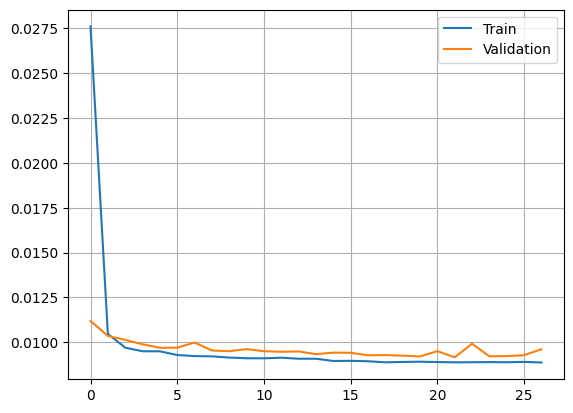

In [ ]:
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.grid()
plt.show()


###**Interpretation**


\- first few epochs : trainig drop sharly -> model quickly learn basic patterns in the data

\- validation loss follow the trainig loss : validation loss decreases as well , showing that the model is **learning general patterns** not just memorizing the trainig data

\- after 10th epoch , the model is improving slowly (stable in the graph) which mean that it has learned most patterns it can

\- as there isnolarge gap betwen training and validation loss : its mean  low overfitting so the model generalizes well to unseen data

      the model quickly learns the patterns in the few first epochs , then stabilizes and since the trainig and validation loss are close , its generalizing well without overfitting

##**testing the model**

- predict the value on x_test
- convert scaled predicitons back to original values
- calculate Metrics RMSE and MAE
- plot the results

214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


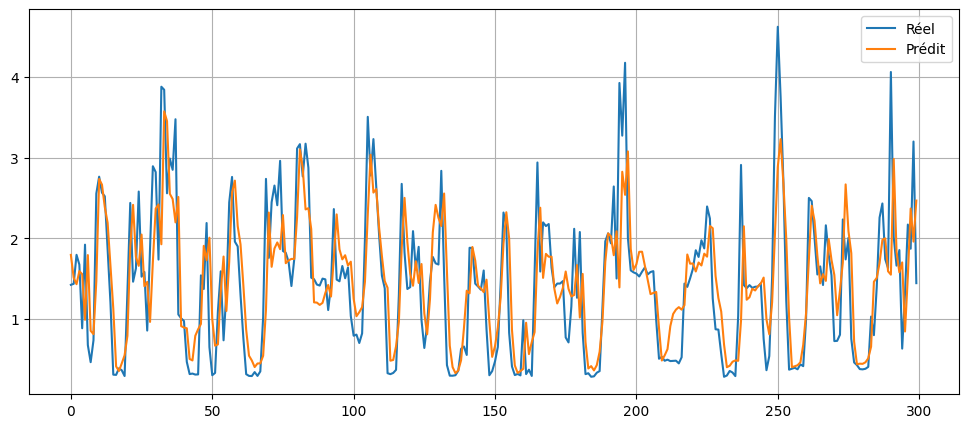

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)

y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

rmse, mae
plt.figure(figsize=(12,5))
plt.plot(y_test_inv[:300], label="Réel")
plt.plot(y_pred_inv[:300], label="Prédit")
plt.legend()
plt.grid()
plt.show()



###**Interpretation**

 The figure compares the **real hourly electricity consumption** with the values **predicted** by the Transformer model on the test dataset.

      the predicted curve closely follows the real consumption, showing that the model successfully learned the main temporal patterns of the time series.